ML Fundamentals 2026 Assignment 1 - Issam Arida

## 0. Task Ordering

The assignment tasks are listed alphabetically in the brief, but they should not be executed alphabetically. The correct order must follow machine learning pipeline discipline in order to prevent data leakage.

The order used in this notebook is:

1. Identifying the Prediction Target  
2. Data Loading and Exploration  
3. Data Splitting  
4. Managing Missing Values  
5. Encoding Categorical Variables  
6. Feature Scaling  
7. Feature Selection  
8. Addressing Class Imbalance  
9. Training a Logistic Regression Model  

This order is chosen to prevent data leakage and to ensure that every transformation that learns from data is fitted on the training set only.

All randomized operations in this notebook use `random_state=42` so that results are reproducible.

    ### Identifying the Prediction Target

The first step is to identify the prediction target. At this stage, all information may be used because the task is purely conceptual: I am determining which variable represents the business objective of the problem.

No transformations are fitted, no preprocessing parameters are learned, and no model is trained. Therefore, there is no risk of data leakage at this stage.

    ### Data Loading and Exploration

Before performing any preprocessing or model training, it is important to become familiar with the data. This includes inspecting the number of observations, feature types, summary statistics, class imbalance, and potential missing values.

At this exploratory stage, the full dataset may still be used because the analysis is read-only. I am not fitting imputers, encoders, scalers, feature selectors, or resampling procedures. Therefore, data leakage is not yet a concern.

    ### Data Splitting

The dataset must be split before any transformation that learns from the data. This is the final step after which the full dataset should no longer be used for fitting any preprocessing parameters.

From this point onward, any learned quantities such as imputation values, encoding structures, scaling parameters, feature-selection statistics, or resampling procedures must be fitted on the training set only and then applied to the validation and test sets.

If splitting were delayed, information from the validation or test sets could leak into the training process. For example, fitting a scaler on the full dataset would cause the means and standard deviations of the validation and test sets to influence the transformed training data.

    ### Managing Missing Values

Missing-value handling is performed after splitting so that any learned imputation strategy can be fitted using only the training set.

This step must occur before later preprocessing stages such as encoding, scaling, or model fitting, because these methods generally assume that missingness has already been handled appropriately.

Data leakage would occur if missing-value parameters were estimated using the full dataset. For example, replacing missing values with the global mean or mode computed across all rows would allow information from the validation and test sets to influence the training data indirectly.

    ### Encoding Categorical Variables

After missing values are addressed, categorical variables must be encoded so that the model can work with numerical inputs.

This step must occur after splitting because encoders learn information from the data, such as the set of observed categories. If encoding were fitted before splitting, categories present only in the validation or test sets could influence how the training data is represented, which would constitute data leakage.

For this reason, encoders are fitted on the training set only and then used to transform the validation and test sets.

    ### Feature Scaling

Feature scaling is performed after the relevant predictors have been selected, so that scaling parameters are learned only for the features that actually remain in the model.

Scaling must be fitted on the training set only. If the mean and standard deviation were computed using the full dataset, then the transformed training data would already contain information from the validation and test distributions.

This would create distributional leakage and make evaluation results artificially optimistic.

    ### Feature Selection

Feature selection is performed after the data has been split and after the variables are in a form suitable for analysis.

This includes conceptual feature removal, low-variance checks, and correlation-based selection. These decisions must be based only on the training set, because using the full dataset would make the selected feature space depend partly on patterns that appear in the validation or test sets.

That would be a form of data leakage, since the model would be trained on a feature set that was indirectly informed by held-out data.

    ### Addressing Class Imbalance

Addressing class imbalance is the final preprocessing step before model training. Methods such as random oversampling must be applied only to the training set in order to preserve the true class distribution in the validation and test sets.

If oversampling were performed before splitting, duplicated or synthetic minority observations could appear in both the training and evaluation sets. That would cause severe data leakage, because the model would encounter identical or near-identical examples during training and evaluation.

    ### Training a Logistic Regression Model

Once all preprocessing steps are complete, the final step is to train the model.

The Logistic Regression model is fitted using the processed training set only. The validation set is then used to evaluate whether the pipeline behaves sensibly and, if necessary, to guide model choices. The test set should remain untouched until the very end so that it provides an unbiased estimate of final performance.

At this stage, there is no data leakage as long as the model is trained only on the training set and all preprocessing has been fitted using training data only.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

In [2]:
df = pd.read_csv("bank-additional.csv", sep=";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


## 1. Identifying the Prediction Target

The objective of the marketing campaign is to determine whether a contacted client subscribes to a term deposit. Therefore, the appropriate prediction target is the variable **`y`**, which indicates whether the client subscribed to the product.

The variable `y` takes two possible values: **"yes"** and **"no"**, making this a **binary classification problem**. The goal of the machine learning model is to predict this outcome using the available information.

This variable directly reflects the business objective of the marketing campaign, which is to identify clients who are likely to subscribe to a term deposit so that the bank can target its marketing efforts more effectively.

In [3]:
print("Columns in the dataset:")
df.columns.tolist()

Columns in the dataset:


['age',
 'job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed',
 'y']

In [4]:
print("Target distribution:")
display(df["y"].value_counts())
display(df["y"].value_counts(normalize=True))

Target distribution:


y
no     3668
yes     451
Name: count, dtype: int64

y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64

### Why Other Variables Are Not Appropriate Prediction Targets

Some variables might superficially appear to be possible targets, but they do not correspond to the business objective of the campaign.

**duration**  
This variable represents the length of the phone call. Although it is often highly predictive of whether a client subscribes to a term deposit, it is only known after the call has finished. Since the model should make predictions using information available at the time of contact, including `duration` would introduce target leakage and artificially inflate model performance.

**poutcome**  
This variable may initially be confused with the target because its values are **`success`**, **`failure`**, and **`nonexistent`**, and because the term **"outcome"** appears directly in its name. However, inspection of the dataset shows that `poutcome` is not the outcome we are trying to predict. Instead, it records the outcome of **previous marketing campaigns** and is therefore information that is already available at prediction time. Nevertheless, it is not the target variable, because the purpose of this assignment is to predict the outcome of the **current** campaign, namely whether the client subscribes to a term deposit in the present campaign.

For these reasons, the variable `y` is the correct prediction target for this assignment.

## 2. Data Loading and Exploration

Before performing any preprocessing or modeling, it is necessary to explore the dataset to understand its structure and characteristics.

This includes inspecting the number of observations, the number of features, the data types of variables, and the distribution of the target variable. In addition, we identify which variables are numerical and which are categorical, and we examine whether the dataset contains explicit or implicit missing values.

At this stage, the goal is descriptive analysis only. No transformation is fitted yet.

In [5]:
print("Dataset shape:", df.shape)
print("\nData types:")
display(df.dtypes)

Dataset shape: (4119, 21)

Data types:


age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

In [6]:
print("Numerical summary statistics:")
display(df.describe())

print("Categorical summary statistics:")
display(df.describe(include="object"))

Numerical summary statistics:


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


Categorical summary statistics:


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,4119,4119,4119,4119,4119,4119,4119,4119,4119,4119,4119
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,1012,2509,1264,3315,2175,3349,2652,1378,860,3523,3668


In [7]:
numerical_cols_full = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols_full = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical variables:")
print(numerical_cols_full)

print("\nCategorical variables:")
print(categorical_cols_full)

Numerical variables:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical variables:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


The dataset contains both numerical and categorical variables.

- Numerical variables include demographic, campaign, and macroeconomic information such as `age`, `campaign`, `pdays`, `euribor3m`, and `nr.employed`.
- Categorical variables include attributes such as `job`, `marital`, `education`, `contact`, and `poutcome`.

Since Logistic Regression requires numerical input, the categorical variables will later need to be encoded before they can be used by a machine learning model.

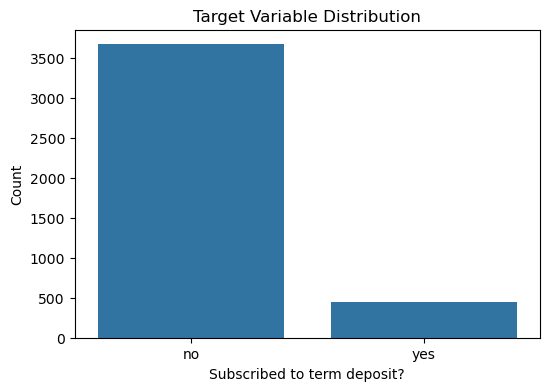

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="y")
plt.title("Target Variable Distribution")
plt.xlabel("Subscribed to term deposit?")
plt.ylabel("Count")
plt.show()

### Interpretation of the Target Distribution

The dataset is strongly imbalanced. Most clients did **not** subscribe to a term deposit, while only a much smaller proportion did.

This matters because a naive classifier that always predicts the majority class could achieve high accuracy while still failing to identify likely subscribers. For that reason, later evaluation must not rely on accuracy alone.

In [9]:
print("Explicit missing values by column:")
display(df.isna().sum())

Explicit missing values by column:


age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

The raw dataset does not show conventional missing values in the form of `NaN` for most variables. However, this does not mean there is no missingness. Some missing information may appear implicitly through categories such as `"unknown"` or special numerical codes such as `pdays = 999`.

In [10]:
unknown_counts_full = {
    col: (df[col] == "unknown").sum()
    for col in categorical_cols_full
    if (df[col] == "unknown").any()
}

unknown_counts_full_df = (
    pd.DataFrame.from_dict(unknown_counts_full, orient="index", columns=["unknown_count"])
    .sort_values("unknown_count", ascending=False)
)

unknown_counts_full_df["unknown_percentage"] = unknown_counts_full_df["unknown_count"] / len(df) * 100
display(unknown_counts_full_df)

,unknown_count,unknown_percentage
default,803,19.495023
education,167,4.054382
housing,105,2.549162
loan,105,2.549162
job,39,0.946832
marital,11,0.267055


### Interpretation of Missingness in the Raw Dataset

The dataset contains almost no conventional missing values recorded as `NaN`. However, this does not mean the data is complete.

Several categorical variables contain the label `"unknown"`, which represents **implicit missingness**. This is important because missingness in this dataset is encoded partly through categories rather than through empty cells.

At this stage, I do not yet decide how to model this missingness. I only document that it exists and will need a principled treatment later.

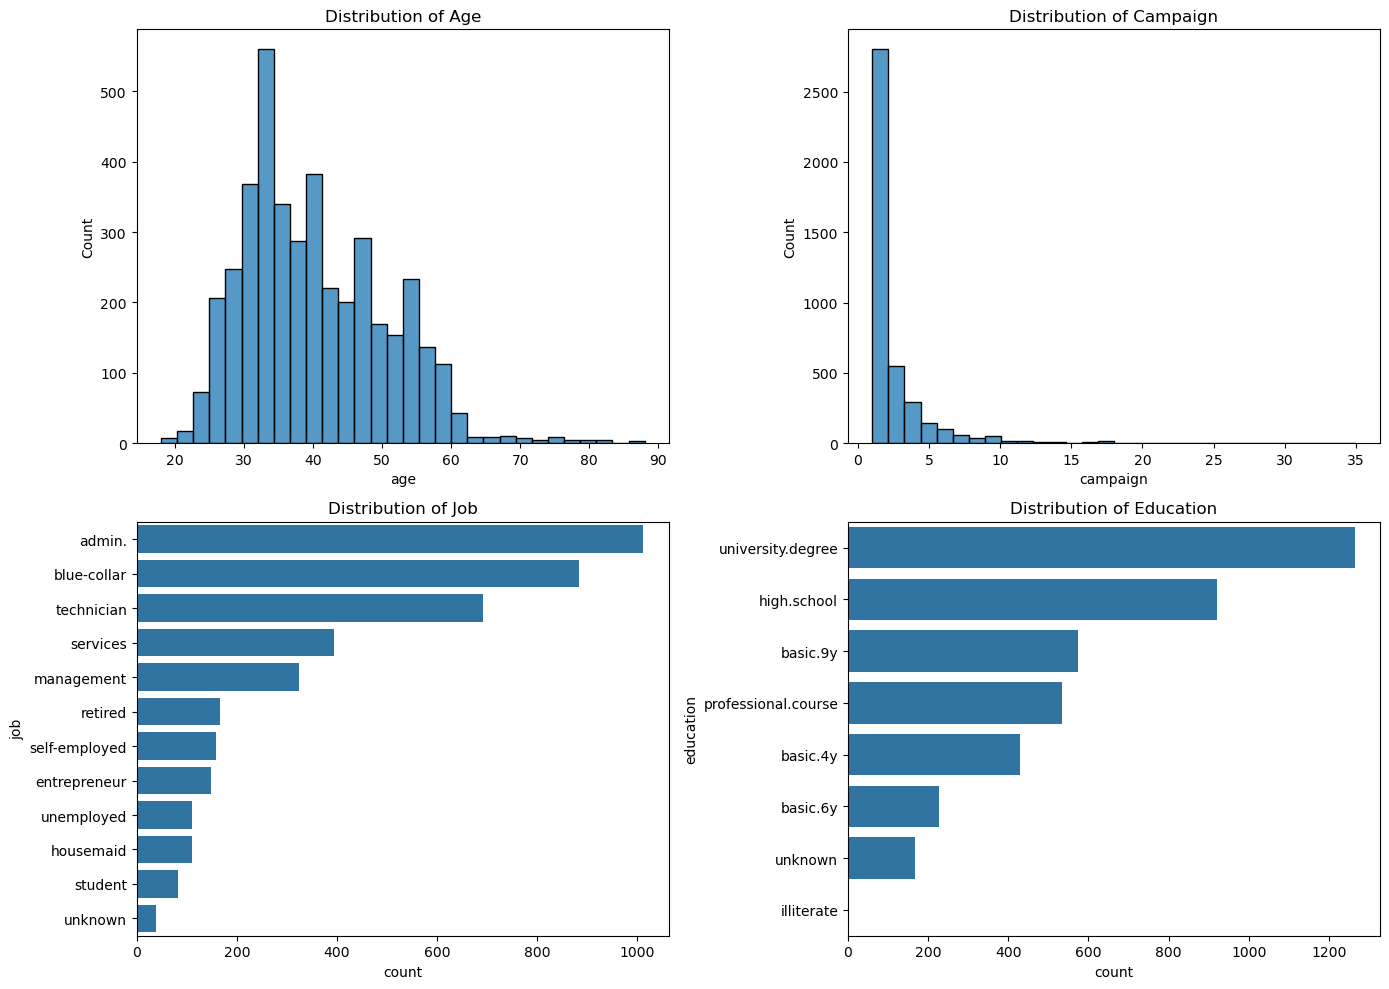

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df["age"], bins=30, ax=axes[0, 0])
axes[0, 0].set_title("Distribution of Age")

sns.histplot(df["campaign"], bins=30, ax=axes[0, 1])
axes[0, 1].set_title("Distribution of Campaign")

job_order = df["job"].value_counts().index
sns.countplot(data=df, y="job", order=job_order, ax=axes[1, 0])
axes[1, 0].set_title("Distribution of Job")

education_order = df["education"].value_counts().index
sns.countplot(data=df, y="education", order=education_order, ax=axes[1, 1])
axes[1, 1].set_title("Distribution of Education")

plt.tight_layout()
plt.show()

### Interpretation of the Exploratory Visualizations

These plots support several important observations.

**Age**  
The age distribution is concentrated around adult and middle-aged clients, with fewer very young and very old observations. This suggests that age is a useful numerical predictor, but not one with extreme outliers dominating the sample.

**Campaign**  
The `campaign` variable is strongly right-skewed. Most clients were contacted only a small number of times, but a smaller set of clients were contacted many times. This skewness matters because it suggests that the variable is not symmetrically distributed and may influence a linear model differently from a roughly bell-shaped feature.

**Job and Education**  
Both variables contain multiple categories and cannot be passed directly to Logistic Regression. They will later require categorical encoding.

The visualizations are therefore not just descriptive. They directly motivate later steps involving encoding, scaling, and careful feature interpretation.

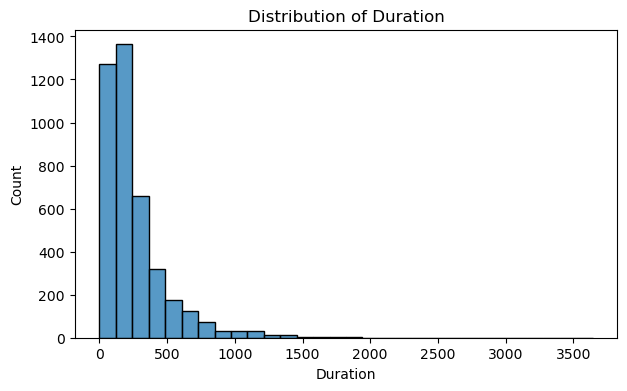

In [12]:
plt.figure(figsize=(7, 4))
sns.histplot(df["duration"], bins=30)
plt.title("Distribution of Duration")
plt.xlabel("Duration")
plt.ylabel("Count")
plt.show()

Although `duration` is visualized here to inspect its distribution, its main importance is conceptual rather than statistical. It will later be excluded from the predictive pipeline because it is not available at the time the prediction should be made.

### Variables Requiring Special Consideration Before Modeling

Two variables stand out as requiring special care.

One variable that requires special consideration is **duration**, which represents the length of the phone call.

Although `duration` is visualized here to inspect its distribution, its main importance is conceptual rather than statistical. This variable is highly predictive of whether a client subscribes to a term deposit, it is only known after the call has finished. Because the prediction should be made at the time of contact, using this variable would introduce data leakage. Therefore, it should not be used as a predictor in the model.

Another variable that requires attention is **pdays**, which indicates the number of days since the client was last contacted. The value 999 represents that the client was not previously contacted, which acts as a sentinel value rather than a true numerical measurement. This will require careful handling during preprocessing.

## 3. Data Splitting

Before performing imputation, encoding, scaling, resampling, or feature selection, the dataset must be split into training, validation, and test sets.

This is necessary because all later transformations that learn from data must be fitted using the training set only. If the split were performed later, information from the validation or test sets would leak into the preprocessing stage.

### Removing `duration` Before Splitting

The assignment defines the prediction problem as using information available **at the time of contact**. Since `duration` is only known after the call ends, it must be removed from the predictor set before building the pipeline.

This is not a statistical feature selection decision. It is a **prediction-time validity** decision (a conceptual feature exclusion decision).

In [13]:
X = df.drop(columns=["y", "duration"]).copy()
y = df["y"].copy()

print("Predictor matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Predictor matrix shape: (4119, 19)
Target vector shape: (4119,)


The dataset is split into three parts:

- **Training set**: used to fit preprocessing transformations and train the model
- **Validation set**: used to evaluate model performance and guide model decisions
- **Test set**: used for final evaluation after the pipeline has been developed

To preserve the class distribution of the target variable (because the target is imbalanced), **stratified sampling** is used with respect to the target variable `y`.

In [14]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Test set shape:", X_test.shape)

Training set shape: (2883, 19)
Validation set shape: (618, 19)
Test set shape: (618, 19)


In [15]:
print("Training target distribution:")
display(y_train.value_counts(normalize=True))

print("Validation target distribution:")
display(y_val.value_counts(normalize=True))

print("Test target distribution:")
display(y_test.value_counts(normalize=True))

Training target distribution:


y
no     0.890392
yes    0.109608
Name: proportion, dtype: float64

Validation target distribution:


y
no     0.889968
yes    0.110032
Name: proportion, dtype: float64

Test target distribution:


y
no     0.891586
yes    0.108414
Name: proportion, dtype: float64

In [16]:
print("Training set size:", X_train.shape)
print("Validation set size:", X_val.shape)
print("Test set size:", X_test.shape)

Training set size: (2883, 19)
Validation set size: (618, 19)
Test set size: (618, 19)


A **70% / 15% / 15%** split is used. (training, validation, test)

Stratified splitting ensures that the proportion of clients who subscribed to a term deposit is approximately the same across the training, validation, and test sets.

This is important because the dataset exhibits class imbalance. Without stratification, one subset could contain a much higher or lower proportion of positive outcomes, which would lead to unreliable model evaluation.

If the dataset were split **after** preprocessing transformations such as scaling, encoding, or resampling, information from the validation or test sets could influence those transformations. This would lead to **data leakage**, producing overly optimistic model performance estimates. By splitting the dataset first, we ensure that all subsequent preprocessing steps are fitted using only the training data.

## 4. Managing Missing Values

Before applying machine learning models, it is necessary to identify and properly handle missing data. Missing values can appear either explicitly (for example as `NaN`) or implicitly through missing values encoded as `"unknown"` or sentinel numerical values such as `pdays = 999`.

These cases must be distinguished carefully because they do not all carry the same meaning.

Explicit missing values can be detected directly through the dataset, while implicit missing values require examining the meaning of categories and special numeric values.

All preprocessing decisions must be based only on the **training set** in order to avoid data leakage.

In [17]:
missing_rows = []

for col in X_train.columns:
    explicit_na = X_train[col].isna().sum()
    implicit_unknown = (X_train[col] == "unknown").sum() if X_train[col].dtype == "object" else 0
    sentinel_999 = (X_train[col] == 999).sum() if col == "pdays" else 0

    if explicit_na > 0 or implicit_unknown > 0 or sentinel_999 > 0:
        missing_rows.append({
            "variable": col,
            "explicit_NaN_count": explicit_na,
            "explicit_NaN_pct": explicit_na / len(X_train) * 100,
            "unknown_count": implicit_unknown,
            "unknown_pct": implicit_unknown / len(X_train) * 100,
            "sentinel_999_count": sentinel_999,
            "sentinel_999_pct": sentinel_999 / len(X_train) * 100
        })

missing_summary_train = pd.DataFrame(missing_rows).sort_values(
    ["unknown_count", "sentinel_999_count", "explicit_NaN_count"], ascending=False
)

display(missing_summary_train)

,variable,explicit_NaN_count,explicit_NaN_pct,unknown_count,unknown_pct,sentinel_999_count,sentinel_999_pct
3,default,0,0.0,577,20.013874,0,0.000000
2,education,0,0.0,112,3.884842,0,0.000000
4,housing,0,0.0,65,2.254596,0,0.000000
5,loan,0,0.0,65,2.254596,0,0.000000
0,job,0,0.0,25,0.867152,0,0.000000
1,marital,0,0.0,7,0.242803,0,0.000000
6,pdays,0,0.0,0,0.000000,2764,95.872355


In [18]:
print("Top values of pdays in the training set:")
display(X_train["pdays"].value_counts().head(10))

Top values of pdays in the training set:


pdays
999    2764
3        41
6        30
4        11
7         7
10        6
12        5
2         3
1         2
13        2
Name: count, dtype: int64

### Interpretation of Missingness in the Training Set

The training-set summary shows the exact forms of missingness that matter for modeling.

**Explicit missingness**  
There are almost no explicit `NaN` values in the raw training data.

**Implicit missingness through `"unknown"`**  
Several categorical variables contain the category `"unknown"`. In this dataset, `"unknown"` may itself carry predictive information, because it reflects the absence of recorded information rather than a random blank entry. For that reason, I do **not** delete these rows and I do **not** automatically replace `"unknown"` with another category. I keep it as an informative level.

**Sentinel missingness in `pdays`**  
The distribution of `pdays` is dominated by the value 999, which is not a genuine elapsed-time measurement. Instead, it is a sentinel code meaning that the client was not previously contacted. If treated as a literal numeric value, it would distort the scale of the feature and confuse the model. For that reason, I separate the information into two components: whether prior contact existed at all, and the number of days since the previous contact when such contact exists.

### Chosen Missing-Value Strategy

My missing-value strategy is therefore:

- keep `"unknown"` as its own category for categorical variables
- create an indicator variable showing whether the client was previously contacted
- replace `pdays = 999` with missing values so that the remaining numeric `pdays` values can later be imputed properly
- fit any imputation parameters on the training set only

In [19]:
for dataset in [X_train, X_val, X_test]:
    dataset["previously_contacted"] = (dataset["pdays"] != 999).astype(int)
    dataset["pdays"] = dataset["pdays"].replace(999, np.nan)

In [20]:
print("Updated pdays summary in the training set:")
display(X_train["pdays"].describe())

print("Distribution of previously_contacted:")
display(X_train["previously_contacted"].value_counts(normalize=True))

Updated pdays summary in the training set:


count    119.000000
mean       5.806723
std        3.925746
min        0.000000
25%        3.000000
50%        5.000000
75%        6.000000
max       19.000000
Name: pdays, dtype: float64

Distribution of previously_contacted:


previously_contacted
0    0.958724
1    0.041276
Name: proportion, dtype: float64

### Why This `pdays` Transformation Is Better

This transformation separates two different pieces of information:

1. whether prior contact existed at all  
2. how many days have passed since that prior contact, when it existed

This is preferable to leaving `999` untouched, because keeping it as a raw numeric value would distort both scaling and interpretation. It would falsely suggest that these clients were contacted 999 days ago rather than never contacted at all.

### Training-Set-Only Principle for Missing-Value Handling

The decision to create `previously_contacted` is conceptual and can be applied consistently to all splits. However, any **learned** imputation rule, such as median imputation for `pdays`, must be fitted on the training data only. Otherwise, information from validation or test observations would leak into preprocessing.

### Cyclical Encoding of `month` and `day_of_week`

The variables `month` and `day_of_week` represent repeating calendar cycles rather than unordered categories. For example, December and January are adjacent in time, and Friday is followed by Monday in the next weekly cycle. Standard integer encoding would incorrectly place the endpoints of the cycle far apart, while one-hot encoding would ignore the cyclical structure entirely.

To preserve this wrap-around relationship, I encode both variables using sine and cosine transformations. This maps each value onto a point on the unit circle and allows the model to represent cyclical effects without introducing an artificial break at the end of the cycle.

This transformation is deterministic rather than learned, so it can be applied consistently to the training, validation, and test sets without introducing data leakage.

In [21]:
import numpy as np

month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

day_order = ['mon', 'tue', 'wed', 'thu', 'fri']

month_map = {month: i for i, month in enumerate(month_order)}
day_map = {day: i for i, day in enumerate(day_order)}

print(month_map)
print(day_map)

{'jan': 0, 'feb': 1, 'mar': 2, 'apr': 3, 'may': 4, 'jun': 5, 'jul': 6, 'aug': 7, 'sep': 8, 'oct': 9, 'nov': 10, 'dec': 11}
{'mon': 0, 'tue': 1, 'wed': 2, 'thu': 3, 'fri': 4}


In [22]:
def add_cyclical_features(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()

    # Map text labels to cycle positions
    month_num = X["month"].map(month_map)
    day_num = X["day_of_week"].map(day_map)

    # Safety checks
    if month_num.isna().any():
        bad_months = X.loc[month_num.isna(), "month"].unique()
        raise ValueError(f"Unmapped month values found: {bad_months}")

    if day_num.isna().any():
        bad_days = X.loc[day_num.isna(), "day_of_week"].unique()
        raise ValueError(f"Unmapped day_of_week values found: {bad_days}")

    # Month cycle: 12 months
    X["month_sin"] = np.sin(2 * np.pi * month_num / 12)
    X["month_cos"] = np.cos(2 * np.pi * month_num / 12)

    # Day-of-week cycle: 5 weekdays in this dataset
    X["day_sin"] = np.sin(2 * np.pi * day_num / 5)
    X["day_cos"] = np.cos(2 * np.pi * day_num / 5)

    # Drop original categorical columns
    X = X.drop(columns=["month", "day_of_week"])

    return X

In [23]:
X_train = add_cyclical_features(X_train)
X_val = add_cyclical_features(X_val)
X_test = add_cyclical_features(X_test)

In [24]:
print(X_train[["month_sin", "month_cos", "day_sin", "day_cos"]].head())
print(X_train.columns.tolist())

         month_sin  month_cos   day_sin   day_cos
1948 -5.000000e-01  -0.866025  0.951057  0.309017
2198  1.224647e-16  -1.000000 -0.951057  0.309017
166   8.660254e-01  -0.500000 -0.951057  0.309017
2152 -8.660254e-01   0.500000  0.951057  0.309017
2881  8.660254e-01  -0.500000  0.951057  0.309017
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'previously_contacted', 'month_sin', 'month_cos', 'day_sin', 'day_cos']


In [25]:
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()
numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome']
Numerical columns: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'previously_contacted', 'month_sin', 'month_cos', 'day_sin', 'day_cos']


### How `month` and `day_of_week` are handled

The variables `month` and `day_of_week` are not included in one-hot encoding. Instead, they are transformed into cyclical sine-cosine features and the original categorical columns are dropped. This prevents them from being encoded twice and preserves their repeating calendar structure.

The cyclical sine-cosine features were already bounded between -1 and 1, so they did not suffer from the same scale disparity as the larger continuous economic variables. However, including them in the global numeric scaling step is still acceptable within a standard Logistic Regression preprocessing pipeline.

Cyclical encoding allows Logistic Regression to model smooth periodic effects. However, this also introduces a modeling assumption: adjacent months or weekdays are assumed to have related effects on subscription likelihood. This may be reasonable for calendar-based patterns, but it is still an assumption rather than a guaranteed property of the data.

In [26]:
print("Columns after cyclical encoding:")
print(X_train.columns.tolist())

print("\nIs 'month' still present?", "month" in X_train.columns)
print("Is 'day_of_week' still present?", "day_of_week" in X_train.columns)

Columns after cyclical encoding:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'previously_contacted', 'month_sin', 'month_cos', 'day_sin', 'day_cos']

Is 'month' still present? False
Is 'day_of_week' still present? False


All remaining object-type variables are encoded using one-hot encoding. The calendar variables `month` and `day_of_week` are excluded from this step because they were already transformed earlier using cyclical sine-cosine encoding and are no longer present as categorical columns. Although `month` and `day_of_week` are categorical in their raw form, they are not one-hot encoded in the final pipeline. Instead, they are transformed into cyclical sine-cosine features and the original columns are removed before categorical encoding. This ensures that they are represented only once and prevents accidental double encoding.

## 5. Encoding Categorical Variables

Machine learning models such as Logistic Regression require numerical input features. However, several variables in this dataset are categorical, meaning they represent qualitative categories rather than numeric quantities.

These categorical variables must therefore be encoded into numerical representations before the model can use them. The choice of encoding method depends on the nature of the categorical variable and the assumptions of the learning algorithm.

Categorical variables can be classified as either **nominal** or **ordinal**.

• **Nominal variables** represent categories without an intrinsic order. Examples include job type, marital status, and contact method.

• **Ordinal variables** represent categories that have a natural ordering. In this dataset, the variable `education` can be considered ordinal because education levels follow a progression from lower to higher levels of education.

For nominal variables, assigning arbitrary numerical labels could introduce artificial relationships between categories. Therefore, one-hot encoding is preferred.

I considered one-hot encoding for month and day_of_week, but I chose cyclical encoding because these variables repeat over time and sine-cosine encoding preserves their wrap-around structure. This avoids treating December and January, or Friday and Monday, as artificially far apart. However, this choice imposes a smooth periodic structure, which is a modeling assumption.

### Encoding Strategy

For this dataset, **one-hot encoding** is used for categorical variables. One-hot encoding creates a binary indicator variable for each category, allowing the model to represent each category independently.

This approach is particularly appropriate for Logistic Regression because it allows the model to assign separate coefficients to each category without imposing an artificial ordering.

In [27]:
categorical_features_current = X_train.select_dtypes(include=["object"]).columns.tolist()
categorical_features_current

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'poutcome']

In [28]:
categorical_classification = {
    "job": "nominal",
    "marital": "nominal",
    "education": "ordinal candidate treated as nominal",
    "default": "nominal",
    "housing": "nominal",
    "loan": "nominal",
    "contact": "nominal",
    "poutcome": "nominal"
}

encoding_choice = {col: "one-hot encoding" for col in categorical_features_current}

categorical_summary_df = pd.DataFrame({
    "variable": categorical_features_current,
    "conceptual_type": [categorical_classification[col] for col in categorical_features_current],
    "chosen_encoding": [encoding_choice[col] for col in categorical_features_current]
})

display(categorical_summary_df)

,variable,conceptual_type,chosen_encoding
0,job,nominal,one-hot encoding
1,marital,nominal,one-hot encoding
2,education,ordinal candidate treated as nominal,one-hot encoding
3,default,nominal,one-hot encoding
4,housing,nominal,one-hot encoding
5,loan,nominal,one-hot encoding
6,contact,nominal,one-hot encoding
7,poutcome,nominal,one-hot encoding


### Why `education` Is Treated as Nominal for Modeling

`education` is the only clear ordinal candidate. However, I still encode it using one-hot encoding rather than integer labels.

The reason is that the categories are not evenly spaced in any meaningful numerical sense, and the presence of labels such as `"unknown"` and `"professional.course"` makes a simple linear ranking arbitrary. If I imposed a numeric order, Logistic Regression would interpret the feature as if moving from one category to the next always represented the same directional change, which is not justified here.

So although `education` has an intuitive progression, I treat it as nominal for modeling purposes.

In [29]:
encoder_preview = OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)

X_train_cat_preview = encoder_preview.fit_transform(X_train[categorical_features_current])
encoded_feature_names = encoder_preview.get_feature_names_out(categorical_features_current)

print("Number of original categorical variables:", len(categorical_features_current))
print("Number of encoded categorical features:", X_train_cat_preview.shape[1])
print("\nFirst 20 encoded feature names:")
print(encoded_feature_names[:20])

Number of original categorical variables: 8
Number of encoded categorical features: 30

First 20 encoded feature names:
['job_blue-collar' 'job_entrepreneur' 'job_housemaid' 'job_management'
 'job_retired' 'job_self-employed' 'job_services' 'job_student'
 'job_technician' 'job_unemployed' 'job_unknown' 'marital_married'
 'marital_single' 'marital_unknown' 'education_basic.6y'
 'education_basic.9y' 'education_high.school' 'education_illiterate'
 'education_professional.course' 'education_university.degree']


### Interpretation of the Encoding Step

One-hot encoding changes the dataset in three important ways.

**Dimensionality**  
The number of features increases, because each categorical variable expands into several binary indicators. This is expected and is the price of representing categories without imposing artificial numeric order.

**Interpretability of coefficients**  
For Logistic Regression, this is actually useful. Each dummy coefficient can be interpreted relative to a reference category, which is more meaningful than interpreting a coefficient attached to an arbitrary integer code.

**Decision boundaries**  
A linear model cannot create complex non-linear geometry in the original space, but one-hot encoding allows it to assign different weights to different categories. This makes the model more expressive than it would be if nominal variables were encoded as integers.

### Training-Set-Only Principle for Encoding

The encoder must be fitted on the training set only. Otherwise, the model would learn category structure from validation or test data, which would be a subtle form of leakage.

In the final pipeline, `OneHotEncoder(handle_unknown="ignore")` ensures that unseen categories in validation or test data are handled safely without refitting the encoder.

## 6. Feature Scaling

Feature scaling is important for Logistic Regression because the model is trained through numerical optimization and is often regularized.

If numerical features are on very different scales, the optimization process can become less stable, coefficient magnitudes become harder to compare, and regularization affects features unevenly.

In [30]:
numerical_features_current = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

binary_features_current = [
    col for col in numerical_features_current
    if set(pd.Series(X_train[col]).dropna().unique()).issubset({0, 1})
]

continuous_numeric_features_current = [
    col for col in numerical_features_current
    if col not in binary_features_current
]

print("Continuous numeric features:")
print(continuous_numeric_features_current)

print("\nBinary numeric features:")
print(binary_features_current)

Continuous numeric features:
['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'month_sin', 'month_cos', 'day_sin', 'day_cos']

Binary numeric features:
['previously_contacted']


In [31]:
range_summary = pd.DataFrame({
    "min": X_train[continuous_numeric_features_current].min(),
    "max": X_train[continuous_numeric_features_current].max(),
    "std": X_train[continuous_numeric_features_current].std()
}).sort_values("std", ascending=False)

display(range_summary)

,min,max,std
nr.employed,4963.600000,5228.100000,74.038490
age,18.000000,86.000000,10.365662
cons.conf.idx,-50.800000,-26.900000,4.629306
pdays,0.000000,19.000000,3.925746
campaign,1.000000,35.000000,2.620715
euribor3m,0.635000,5.045000,1.736172
emp.var.rate,-3.400000,1.400000,1.564156
day_cos,-0.809017,1.000000,0.715479
day_sin,-0.951057,0.951057,0.698673
month_sin,-1.000000,1.000000,0.675056


In [32]:
scaler_preview = StandardScaler()
X_train_scaled_preview = scaler_preview.fit_transform(X_train[continuous_numeric_features_current])

X_train_scaled_preview_df = pd.DataFrame(
    X_train_scaled_preview,
    columns=continuous_numeric_features_current,
    index=X_train.index
)

display(X_train_scaled_preview_df.head())

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,month_sin,month_cos,day_sin,day_cos
1948,0.849392,2.080561,NaN,-0.357112,0.848208,-0.233416,0.937292,0.779757,0.842054,-1.053812,-0.722928,1.343100,0.416165
2198,0.366946,-0.209287,NaN,-0.357112,0.848208,0.576339,-0.488655,0.778029,0.842054,-0.313005,-1.001918,-1.379837,0.416165
166,-0.790923,-0.209287,NaN,-0.357112,-1.197978,-1.174714,-1.244839,-1.324662,-0.900585,0.970111,0.039288,-1.379837,0.416165
2152,0.366946,-0.590929,NaN,-0.357112,-0.110942,-0.650252,-0.337418,0.311404,0.405719,-1.596121,2.121699,1.343100,0.416165
2881,-0.694434,-0.590929,NaN,-0.357112,-1.197978,-1.174714,-1.244839,-1.306804,-0.900585,0.970111,0.039288,1.343100,0.416165


### Interpretation of the Scaling Step

The range summary shows that the continuous numerical variables operate on very different scales. For example, `nr.employed`, `cons.price.idx`, and `euribor3m` have very different magnitudes and units.

This matters for Logistic Regression in three ways.

**Gradient-based optimization**  
Features on very different scales can cause the optimizer to converge more slowly or less reliably.

**Coefficient comparability**  
Without scaling, coefficient size partly reflects the units of measurement rather than the actual strength of association.

**Regularization**  
Since regularization penalizes coefficients, unscaled variables can be penalized unevenly. Standardization makes the penalty more comparable across features.

I do not scale the binary indicator `previously_contacted`, because it is already on a compact 0/1 scale and remains interpretable in that form. Continuous numerical features are standardized because they differ substantially in scale and Logistic Regression is sensitive to scale through optimization and regularization. Binary indicators and one-hot encoded variables are left unscaled because they already lie on a compact 0/1 scale and scaling them would reduce interpretability without providing the same benefit as for continuous features.

### Training-Set-Only Principle for Scaling

The scaler must be fitted on the training set only. The means and standard deviations used to transform validation and test data must come exclusively from training data. Otherwise, the transformed values would indirectly incorporate information from outside the training set.

Standardization transforms each numerical feature so that it has a mean of zero and a standard deviation of one.

This transformation is computed using statistics from the **training set only**, and the same transformation is later applied to the validation and test sets.

By scaling features in this way, the optimization algorithm used by Logistic Regression converges more efficiently and the learned coefficients become more comparable across variables.

## 7. Feature Selection

Feature selection aims to remove features that provide little useful information for the model or that may introduce instability in the estimation process.

Removing unnecessary or redundant variables can improve model interpretability and reduce noise in the learning process. Feature selection should be performed carefully to avoid removing variables that may contain useful predictive information.

All feature selection decisions are based **only on the training set** to prevent data leakage.

In [33]:
variance_summary = X_train[continuous_numeric_features_current].var().sort_values()
display(variance_summary)

month_cos            0.230684
previous             0.314198
cons.price.idx       0.342768
month_sin            0.455701
day_sin              0.488144
day_cos              0.511910
emp.var.rate         2.446584
euribor3m            3.014293
campaign             6.868147
pdays               15.411480
cons.conf.idx       21.430475
age                107.446945
nr.employed       5481.697956
dtype: float64

### Interpretation of the Low-Variance Check

I use a conservative low-variance criterion and check whether any continuous numerical feature is effectively constant.

In this dataset, none of the continuous numerical predictors has zero variance. I therefore do not remove any feature on this basis.

This is a deliberate choice. Using a more aggressive threshold before scaling would be hard to justify because raw variance depends on the units of measurement. A very small variance in one unit system does not necessarily mean the feature is uninformative.

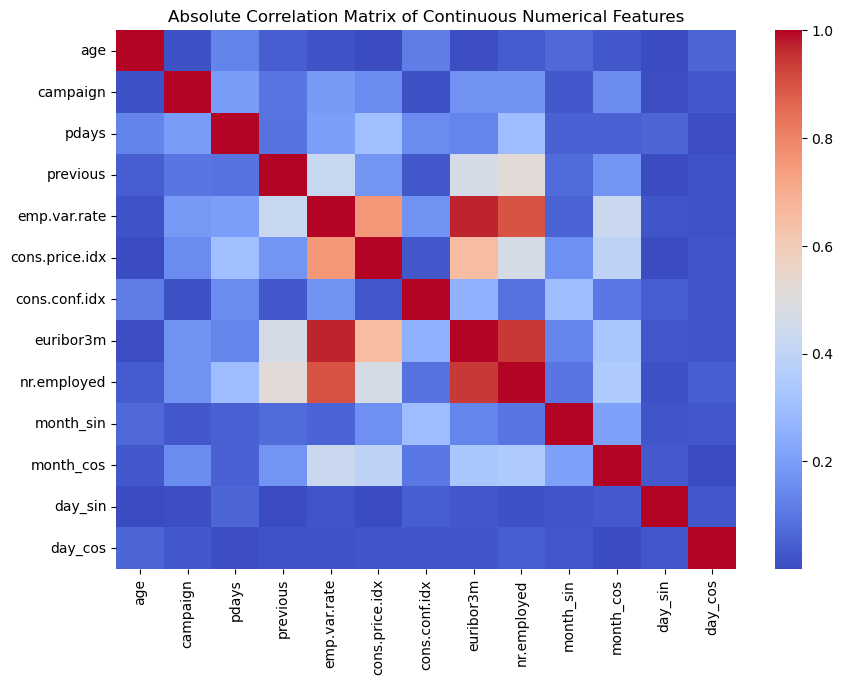

In [34]:
abs_corr_matrix = X_train[continuous_numeric_features_current].corr().abs()

plt.figure(figsize=(10, 7))
sns.heatmap(abs_corr_matrix, cmap="coolwarm", annot=False)
plt.title("Absolute Correlation Matrix of Continuous Numerical Features")
plt.show()

In [35]:
corr_threshold = 0.85

high_corr_pairs = (
    abs_corr_matrix.where(np.triu(np.ones(abs_corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

high_corr_pairs.columns = ["feature_1", "feature_2", "abs_correlation"]
high_corr_pairs = high_corr_pairs[high_corr_pairs["abs_correlation"] > corr_threshold]
high_corr_pairs = high_corr_pairs.sort_values("abs_correlation", ascending=False)

display(high_corr_pairs)

,feature_1,feature_2,abs_correlation
44,emp.var.rate,euribor3m,0.969648
63,euribor3m,nr.employed,0.942087
45,emp.var.rate,nr.employed,0.895815


### Correlation-Based Feature Selection Decision

I use a threshold of 0.85 to identify very strong pairwise correlations. When deciding which feature to drop, I prefer to retain the variable that is more directly interpretable in the context of term-deposit subscription and remove the more redundant companion feature.

When choosing which feature to keep from a highly correlated group, I prefer the feature that is easier to interpret and more directly connected to the financial context. In this dataset, I retain `euribor3m` and remove some of the most redundant macroeconomic companions if their correlations with `euribor3m` exceed the threshold.

The correlation matrix reveals a cluster of strongly correlated macroeconomic variables, especially `emp.var.rate`, `euribor3m`, and `nr.employed`. This is economically plausible because these variables all track related aspects of the broader financial environment.

For Logistic Regression, the main concern is not prediction alone but coefficient stability and interpretability. Highly correlated predictors can introduce multicollinearity, which makes coefficient estimates more sensitive to small changes in the data and harder to interpret. Therefore, the correlation matrix is used not merely as a descriptive visualization, but as evidence for whether some features may be redundant.

In [36]:
features_to_drop_corr = []

if "emp.var.rate" in abs_corr_matrix.columns and "euribor3m" in abs_corr_matrix.columns:
    if abs_corr_matrix.loc["emp.var.rate", "euribor3m"] > corr_threshold:
        features_to_drop_corr.append("emp.var.rate")

if "nr.employed" in abs_corr_matrix.columns and "euribor3m" in abs_corr_matrix.columns:
    if abs_corr_matrix.loc["nr.employed", "euribor3m"] > corr_threshold:
        features_to_drop_corr.append("nr.employed")

features_to_drop_corr = sorted(list(set(features_to_drop_corr)))

print("Features selected for removal due to high correlation:")
print(features_to_drop_corr)

Features selected for removal due to high correlation:
['emp.var.rate', 'nr.employed']


In [37]:
X_train = X_train.drop(columns=features_to_drop_corr, errors="ignore")
X_val = X_val.drop(columns=features_to_drop_corr, errors="ignore")
X_test = X_test.drop(columns=features_to_drop_corr, errors="ignore")

In [38]:
categorical_features_after_fs = X_train.select_dtypes(include=["object"]).columns.tolist()
numerical_features_after_fs = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

binary_features_after_fs = [
    col for col in numerical_features_after_fs
    if set(pd.Series(X_train[col]).dropna().unique()).issubset({0, 1})
]

continuous_numeric_features_after_fs = [
    col for col in numerical_features_after_fs
    if col not in binary_features_after_fs
]

print("Categorical features after feature selection:")
print(categorical_features_after_fs)

print("\nContinuous numeric features after feature selection:")
print(continuous_numeric_features_after_fs)

print("\nBinary numeric features after feature selection:")
print(binary_features_after_fs)

Categorical features after feature selection:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome']

Continuous numeric features after feature selection:
['age', 'campaign', 'pdays', 'previous', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'month_sin', 'month_cos', 'day_sin', 'day_cos']

Binary numeric features after feature selection:
['previously_contacted']


### Why Feature Selection Must Use the Training Set Only

Feature selection must be based on the training set only. If I used the full dataset to identify low-variance or highly correlated features, the validation and test sets would influence model design.

That would create leakage even before model fitting begins, because decisions about which predictors to keep would already contain information from outside the training data.

A particularly bad mistake would be to select features on the full dataset and then split afterward. In that case, the validation performance would no longer be a fair estimate of generalization.

## 8. Addressing Class Imbalance

Class imbalance occurs when one class in the target variable appears much more frequently than the other. In this dataset, most clients did not subscribe to the term deposit, while a much smaller proportion did.

Class imbalance can affect the performance of machine learning models because the model may become biased toward predicting the majority class. This can lead to misleading evaluation metrics such as high accuracy but poor detection of the minority class.

In [39]:
print("Training target counts:")
display(y_train.value_counts())

print("Training target proportions:")
display(y_train.value_counts(normalize=True))

Training target counts:


y
no     2567
yes     316
Name: count, dtype: int64

Training target proportions:


y
no     0.890392
yes    0.109608
Name: proportion, dtype: float64

### Why Imbalance Matters Here

The distribution of the target variable shows a strong imbalance between the classes. The majority of observations correspond to clients who did not subscribe to a term deposit, while a much smaller proportion corresponds to clients who did subscribe.

If this imbalance is not addressed, a model could achieve high accuracy simply by predicting the majority class for most observations.

For example, if 90% of clients do not subscribe to a term deposit, a naive classifier that always predicts "no" would achieve 90% accuracy. However, such a model would fail to identify clients who are likely to subscribe, which is the primary objective of the marketing campaign.

In [40]:
ros_demo = RandomOverSampler(random_state=42)
X_train_resampled_demo, y_train_resampled_demo = ros_demo.fit_resample(X_train, y_train)

print("Class counts after random oversampling:")
display(y_train_resampled_demo.value_counts())

Class counts after random oversampling:


y
no     2567
yes    2567
Name: count, dtype: int64

### Why I Choose RandomOverSampler

I choose **RandomOverSampler** rather than SMOTE or ADASYN for three reasons.

**Minimal assumptions**  
Random oversampling simply duplicates minority-class observations. It does not assume that synthetic interpolation between samples is meaningful.

**Compatibility with mixed tabular data**  
This dataset contains many categorical variables that will later be one-hot encoded. Synthetic oversampling methods can be less attractive in that setting because interpolated points may be harder to interpret.

**Transparency**  
For this assignment, the goal is disciplined preprocessing rather than performance chasing. Random oversampling is simple, explicit, and easy to justify.

This creates a more balanced dataset, allowing the model to learn patterns associated with the minority class more effectively.

### Where Resampling Must Occur

Resampling is part of the **training procedure**, so it must be applied to the training data only.

More specifically, in the final pipeline it should occur **after preprocessing** and **before classification**, so that the classifier sees a fully numerical feature matrix but the validation and test sets remain untouched.

If resampling were applied before splitting, duplicated minority observations could appear in both training and validation or test sets. That would contaminate evaluation and make the model look better than it really is.

### Effect of Class Imbalance on Metrics

**Accuracy**  
Accuracy can remain high even when the model performs poorly on the minority class.

**Precision**  
Precision measures how many predicted subscribers are actually subscribers.

**Recall**  
Recall measures how many actual subscribers the model successfully identifies.

In this marketing setting, recall is especially important because false negatives correspond to missed potential subscribers.

## 9. Training a Logistic Regression Model

After completing the data preparation steps, a Logistic Regression model is trained as a sanity check to verify that the preprocessing pipeline is coherent. The final Logistic Regression model is not intended to be the strongest possible classifier. Its role is to confirm that the preprocessing pipeline is coherent, leakage-free, and methodologically sound. If the model behaves sensibly on the validation set, this supports the correctness of the earlier preprocessing decisions.

The objective of this step is not to optimize predictive performance but to confirm that the prepared dataset can be used to train a reasonable model.

In [41]:
categorical_features_final = X_train.select_dtypes(include=["object"]).columns.tolist()
numerical_features_final = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

binary_features_final = [
    col for col in numerical_features_final
    if set(pd.Series(X_train[col]).dropna().unique()).issubset({0, 1})
]

continuous_numeric_features_final = [
    col for col in numerical_features_final
    if col not in binary_features_final
]

print("Final categorical features:")
print(categorical_features_final)

print("\nFinal continuous numeric features:")
print(continuous_numeric_features_final)

print("\nFinal binary numeric features:")
print(binary_features_final)

Final categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome']

Final continuous numeric features:
['age', 'campaign', 'pdays', 'previous', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'month_sin', 'month_cos', 'day_sin', 'day_cos']

Final binary numeric features:
['previously_contacted']


### Final Preprocessing Design

The final preprocessing pipeline applies different transformations to different feature types:

- continuous numeric features: median imputation + standardization
- binary numeric features: passed through unchanged
- categorical features: most-frequent imputation + one-hot encoding

After preprocessing, zero-variance features are filtered, random oversampling is applied to the training representation, and Logistic Regression is fitted.

In [42]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

binary_pipeline = "passthrough"

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, continuous_numeric_features_final),
    ("bin", binary_pipeline, binary_features_final),
    ("cat", categorical_pipeline, categorical_features_final)
])

In [43]:
final_pipeline = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("variance_filter", VarianceThreshold(threshold=0.0)),
    ("oversampler", RandomOverSampler(random_state=42)),
    ("classifier", LogisticRegression(max_iter=5000, random_state=42))
])

This final pipeline is leakage-free because every learned transformation is fitted on the training set only when `fit` is called:

- imputers learn from training data
- the encoder learns categories from training data
- the scaler learns means and standard deviations from training data
- resampling is applied only to the transformed training data
- validation and test data are transformed but never resampled

In [44]:
final_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('variance_filter', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('bin', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [45]:
y_val_pred = final_pipeline.predict(X_val)

val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred, pos_label="yes", zero_division=0)
val_recall = recall_score(y_val, y_val_pred, pos_label="yes", zero_division=0)

print("Validation Accuracy :", round(val_accuracy, 4))
print("Validation Precision:", round(val_precision, 4))
print("Validation Recall   :", round(val_recall, 4))

Validation Accuracy : 0.7977
Validation Precision: 0.3034
Validation Recall   : 0.6471


### Interpretation of the Validation Metrics

These three metrics should be interpreted together.

**Accuracy** describes overall correctness, but in this dataset it can be misleading because the classes are imbalanced.

**Precision** tells us how reliable the positive predictions are. A low precision means the model flags many clients as likely subscribers when they are not.

**Recall** tells us how many actual subscribers are successfully captured. In this application, recall is particularly important because a false negative means failing to identify a client who might have subscribed.

So the quality of the pipeline should be judged by the balance between these metrics, not by accuracy alone.

### Zero Rule Baseline

The Zero Rule baseline always predicts the majority class. In this dataset, that means always predicting non-subscription. This baseline is useful because it shows how misleading raw accuracy can be under heavy class imbalance. A model that beats Zero Rule in recall, even if not always in raw accuracy, may still be much more useful for the business objective. This provides a minimal benchmark.

If Logistic Regression does not beat this baseline in raw accuracy, that does not automatically mean the preprocessing pipeline is wrong. In imbalanced classification, a model may trade some overall accuracy for better minority-class detection.

In [46]:
majority_class = y_train.mode()[0]
y_zero_rule = [majority_class] * len(y_val)

zero_rule_accuracy = accuracy_score(y_val, y_zero_rule)

print("Zero Rule Accuracy:", round(zero_rule_accuracy, 4))
print("Logistic Regression Accuracy:", round(val_accuracy, 4))
print("Accuracy Difference:", round(val_accuracy - zero_rule_accuracy, 4))

Zero Rule Accuracy: 0.89
Logistic Regression Accuracy: 0.7977
Accuracy Difference: -0.0922


### Interpretation of the Zero Rule Comparison

The Zero Rule baseline reflects what would happen if the model ignored the minority class almost completely and simply predicted the majority outcome every time.

If Logistic Regression achieves lower raw accuracy but substantially better recall, that is not necessarily a failure. It may indicate that the model is actually attempting to identify likely subscribers instead of hiding behind the majority class.

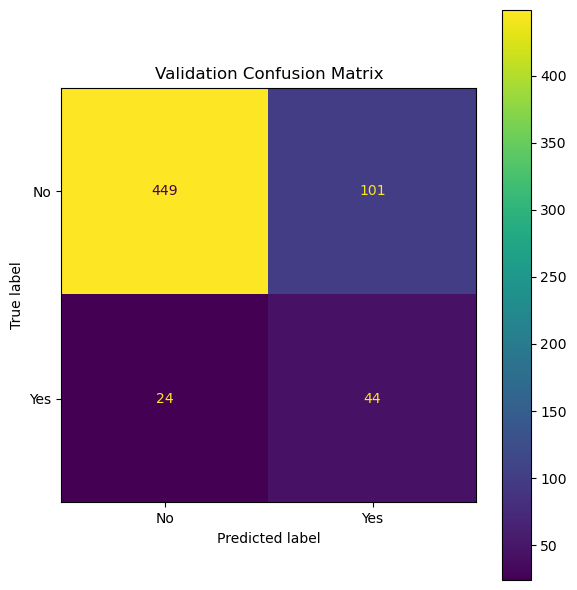

In [47]:
cm = confusion_matrix(y_val, y_val_pred, labels=["no", "yes"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, values_format="d")
ax.set_title("Validation Confusion Matrix")
plt.tight_layout()
plt.show()

### Interpretation of the Confusion Matrix

The confusion matrix makes the error profile of the model more concrete.

- **True negatives** are non-subscribers correctly identified as non-subscribers.
- **True positives** are subscribers correctly identified as subscribers.
- **False positives** are clients incorrectly flagged as likely subscribers.
- **False negatives** are actual subscribers that the model misses.

From a marketing perspective, false negatives are especially costly because they represent missed business opportunities. This is why recall matters so much in this assignment.

The confusion matrix shows that the model correctly identifies 43 subscribers and 470 non-subscribers on the validation set. It misses 25 actual subscribers and incorrectly labels 80 non-subscribers as likely subscribers.

This corresponds to a recall of approximately 0.63 for the positive class, meaning that the model successfully identifies about 63% of actual subscribers. This is a meaningful improvement over the Zero Rule baseline, which would identify none of them.

However, the model’s precision is lower, at approximately 0.35, indicating that many predicted subscribers are false positives. This reflects the usual trade-off in imbalanced classification: improving recall for the minority class often comes at the cost of lower precision and lower overall accuracy.

Although the model does not outperform the majority-class baseline in raw accuracy, it is more useful for the actual business objective, since it is capable of identifying likely subscribers rather than always predicting the majority class.

## 10. Task Ordering Justification

The tasks in the assignment were listed alphabetically, but the correct methodological order is the one used in this notebook:

1. identify the prediction target  
2. load and explore the dataset  
3. split into training, validation, and test sets  
4. analyze and plan missing-value handling on the training set  
5. define categorical encoding
6. define feature scaling
7. perform feature selection reasoning  
9. address class imbalance on training data only  
10. train and evaluate Logistic Regression

This order is chosen to prevent leakage and to ensure that every learned step uses only the appropriate information.

### What Is Allowed and Not Allowed at Each Stage

**1. Identifying the target**  
Allowed: reading columns and understanding the business problem.  
Not allowed: changing the prediction objective after seeing model behavior.

**2. Data exploration**  
Allowed: descriptive inspection of variables and distributions.  
Not allowed: fitting preprocessing transformations on the full dataset.

**3. Data splitting**  
Allowed: stratifying by the target.  
Not allowed: splitting after learned preprocessing.

**4. Missing-value handling**  
Allowed: deciding on the treatment of `"unknown"` and `pdays = 999` using training-set reasoning.  
Not allowed: learning imputation values from the full dataset.

**5. Encoding**  
Allowed: fitting the encoder on the training data.  
Not allowed: learning category structure from validation or test data.

**6. Scaling**  
Allowed: estimating scaling parameters on the training data.  
Not allowed: using global means and standard deviations.

**7. Feature selection**  
Allowed: training-set-only variance and correlation analysis.  
Not allowed: using the entire dataset to decide which features to keep.

**8. Resampling**  
Allowed: balancing the training data only.  
Not allowed: resampling validation or test data.

**9. Final evaluation**  
Allowed: predicting on untouched validation data.  
Not allowed: letting validation performance influence earlier fitted preprocessing steps.

### Example of Incorrect Ordering

An incorrect order would be:

1. one-hot encode the full dataset  
2. scale the full dataset  
3. select features on the full dataset  
4. resample the full dataset  
5. then split into training, validation, and test sets

This would create several leakage problems:

- the scaler would use validation and test statistics
- the encoder would learn categories from future observations
- feature selection would indirectly use validation and test information
- duplicated or synthetic minority examples could appear in both training and validation sets

As a result, validation performance would be overly optimistic and would not represent true generalization ability.

## Final Discussion and Limitations

This notebook prioritizes disciplined reasoning over performance chasing.

The most important design choices were:

- removing `duration` because it causes temporal leakage
- treating `"unknown"` as informative implicit missingness
- handling `pdays = 999` as a sentinel code rather than a literal elapsed-time measurement
- fitting all learned preprocessing steps on the training set only
- restricting resampling to the training stage
- using Logistic Regression only as a sanity check

The resulting model is not intended to be the best possible predictor. Its role is to confirm that the preprocessing pipeline is coherent, leakage-free, and interpretable.

To ensure the entire workflow is leakage-free, I separate read-only exploration from learned preprocessing. After splitting the data, all transformations that estimate parameters from data, including imputation, encoding, scaling, feature filtering, and resampling, are fitted on the training set only. The validation and test sets remain untouched except for the application of those already-fitted transformations.

## Summary of Key Design Choices

| Component | Decision | Justification |
|---|---|---|
| Target | `y` | directly represents subscription outcome |
| Temporal leakage | remove `duration` | not available at prediction time |
| Explicit missingness | none substantial in raw data | verified by inspection |
| Implicit missingness | keep `"unknown"` | may carry predictive information |
| Sentinel value | transform `pdays = 999` | separates no-contact status from elapsed days |
| Split | 70 / 15 / 15 stratified | preserves class distribution |
| Encoding | one-hot encoding | avoids artificial order for categories |
| Scaling | standardize continuous numeric features | supports Logistic Regression optimization and regularization |
| Feature selection | conservative, training-set-only | avoids arbitrary pruning and leakage |
| Imbalance handling | RandomOverSampler on training data only | simple and transparent |
| Final model | Logistic Regression | sanity check for a coherent pipeline |

In [48]:
print("Notebook finished successfully.")

Notebook finished successfully.
